**Healthcare visualisations**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv('../Datasets/healthcare_cleaned.csv')

In [3]:
df

,Unnamed: 0,Patient ID,Age,Age Range,Blood Type,Medical Condition,Date of Admission,Discharge Date,Length of Stay,Billing Amount,Doctor,Hospital,Insurance Provider,Medication,Test Results,Admission Type
0,0,9916905651,30,30 - 44,B-,Cancer,2024-01-31,2024-02-02,2 days,18856.28,Matthew Smith,Sons and Miller,Blue Cross,Paracetamol,Normal,Urgent
1,1,6628734666,62,60 - 74,A+,Obesity,2019-08-20,2019-08-26,6 days,33643.33,Samantha Davies,Kim Inc,Medicare,Ibuprofen,Inconclusive,Emergency
2,2,9816626599,76,75+,A-,Obesity,2022-09-22,2022-10-07,15 days,27955.10,Tiffany Mitchell,Cook PLC,Aetna,Aspirin,Normal,Emergency
3,3,8154724457,28,18 - 29,O+,Diabetes,2020-11-18,2020-12-18,30 days,37909.78,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,Ibuprofen,Abnormal,Elective
4,4,4955904392,43,30 - 44,AB+,Cancer,2022-09-19,2022-10-09,20 days,14238.32,Kathleen Hanna,White-White,Aetna,Penicillin,Abnormal,Urgent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,9995,4035472565,51,45 - 59,O-,Arthritis,2019-09-25,2019-10-03,8 days,5127.44,Isaac Silva,Rice and Sons,Cigna,Ibuprofen,Normal,Urgent
9981,9996,7649764137,61,60 - 74,B-,Diabetes,2020-06-03,2020-06-04,1 days,47855.35,Jose Cohen,"Johnson, Adkins and Ferguson",Aetna,Paracetamol,Normal,Emergency
9982,9997,9381261822,25,18 - 29,B-,Cancer,2024-03-14,2024-03-28,14 days,40787.18,Michael Hess,Kramer-Hogan,UnitedHealthcare,Penicillin,Inconclusive,Elective
9983,9998,3942008370,71,60 - 74,A-,Hypertension,2023-08-22,2023-09-03,12 days,25979.75,Cheryl Faulkner,"Williams Barnes and Fletcher,",Blue Cross,Lipitor,Inconclusive,Emergency


Mean, median, standard deviation, hypothesis testing, and basic probability are all foundational skills for data analysis

The mean is a foundational data analytics tool as it is the average of a collection of numbers, this allo

In [4]:
df["Billing Amount"].median()

np.float64(25665.34)

Here is the median billing amount

In [5]:
df["Billing Amount"].mode()[0]

np.float64(2106.39)

Here is the mode of the billing amount

In [6]:
start = df["Date of Admission"].min()
end = df["Discharge Date"].max()
print("Date range from", start, "to", end)

Date range from 2019-05-08 to 2024-06-02


Here is the range from the first date of entery to the last date of discharge

In [7]:
std = df["Billing Amount"].std()
print("Standard Deviation of Billing Amount:", std)

Standard Deviation of Billing Amount: 14161.772804767472


Here is the standard deviation for the billing amount

In [8]:
start = df["Billing Amount"].min()
end = df["Billing Amount"].max()
print("Billing Amount ranges from", start, "to", end)

Billing Amount ranges from 38.97 to 52271.66


Here is the range for the billing amount

In [9]:
# Convert dates to numeric values (days since epoch)
df['Date_Numeric'] = pd.to_datetime(df['Date of Admission']).astype(np.int64) // 10**9

# Prepare data in correct shape
X = df['Date_Numeric'].values.reshape(-1, 1)  # 2D array for features
y = df['Billing Amount'].values  # 1D array for target

# Fit model
model = LinearRegression()
model.fit(X, y)

# Prepare prediction date
x_predict = pd.to_datetime(['2024-01-31']).astype(np.int64) // 10**9
x_predict = np.array(x_predict).reshape(-1, 1)  # Convert to numpy array before reshaping

# Make prediction
y_predict = model.predict(x_predict)
print(f"Predicted billing amount for 2024-01-31: ${y_predict[0]:.2f}")

Predicted billing amount for 2024-01-31: $25475.79


In [10]:
#x= df[["Date of Admission"]]
#y= df[["Billing Amount"]]

#regressor = LinearRegression()
#regressor.fit(x, y)

#y_pred = regressor.predict(X)

#plt.scatter(x, y, color = 'red')
#plt.plot(x, regressor.predict(x), color = 'blue')
#plt.title('mark1 vs mark2')
#plt.xlabel('mark1')
#plt.ylabel('mark2')
#plt.show()

In [11]:
df["Medical Condition"].value_counts()

Medical Condition
Arthritis       1686
Cancer          1684
Hypertension    1675
Asthma          1654
Diabetes        1654
Obesity         1632
Name: count, dtype: int64

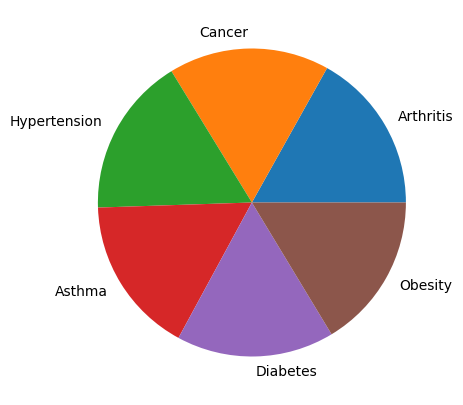

In [12]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(13,5))
categorical_count = df.value_counts('Medical Condition',normalize=True)
plt.pie(x=categorical_count, labels=categorical_count.index)
plt.show()

Here is a pie chart of all the different medical conditions from the dataset. Just above the pie chart I got a count of how often they appear in the datase, aAs we can see from that, there is not a lot more than another, with the range of them being 54, meaning that the pie chart is rather balanced.

In [13]:
df["Age Range"].value_counts()

Age Range
30 - 44    2204
45 - 59    2186
60 - 74    2180
18 - 29    1743
75+        1672
Name: count, dtype: int64

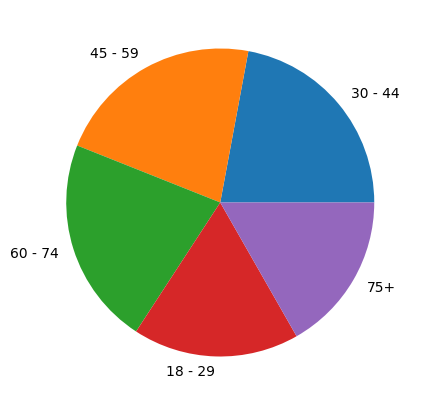

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(13,5))
categorical_count = df.value_counts('Age Range',normalize=True)
plt.pie(x=categorical_count, labels=categorical_count.index)
plt.show()

Here is a pie chart of all the different medical conditions from the dataset. Just above the pie chart I got a count of how often they appear in the datase, aAs we can see from that, there is not a lot more than another, with the range of them being 54, meaning that the pie chart is rather balanced.

In [15]:
df["Insurance Provider"].value_counts()

Insurance Provider
UnitedHealthcare    2012
Blue Cross          2011
Cigna               2004
Aetna               1980
Medicare            1978
Name: count, dtype: int64

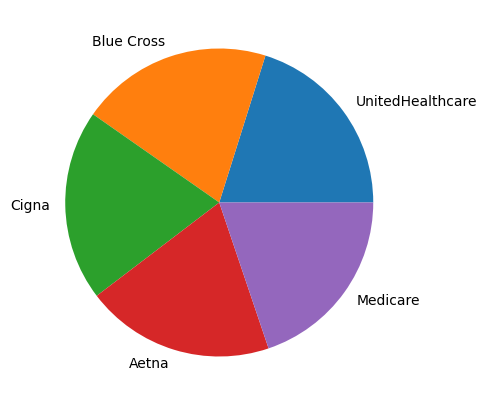

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(13,5))
categorical_count = df.value_counts('Insurance Provider',normalize=True)
plt.pie(x=categorical_count, labels=categorical_count.index)
plt.show()

Here is a pie chart of all the different medical conditions from the dataset. Just above the pie chart I got a count of how often they appear in the datase, aAs we can see from that, there is not a lot more than another, with the range of them being 54, meaning that the pie chart is rather balanced.

In [17]:
df["Blood Type"].value_counts()

Blood Type
AB+    1276
B+     1273
A+     1271
O+     1253
A-     1238
O-     1227
B-     1225
AB-    1222
Name: count, dtype: int64

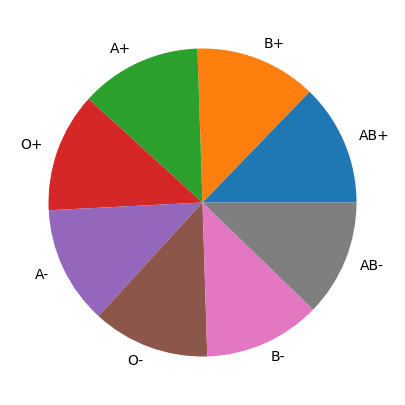

In [18]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(13,5))
categorical_count = df.value_counts('Blood Type',normalize=True)
plt.pie(x=categorical_count, labels=categorical_count.index)
plt.show()

Here is a pie chart of all the different medical conditions from the dataset. Just above the pie chart I got a count of how often they appear in the datase, aAs we can see from that, there is not a lot more than another, with the range of them being 54, meaning that the pie chart is rather balanced.

In [19]:
df["Blood Type"].value_counts()

Blood Type
AB+    1276
B+     1273
A+     1271
O+     1253
A-     1238
O-     1227
B-     1225
AB-    1222
Name: count, dtype: int64

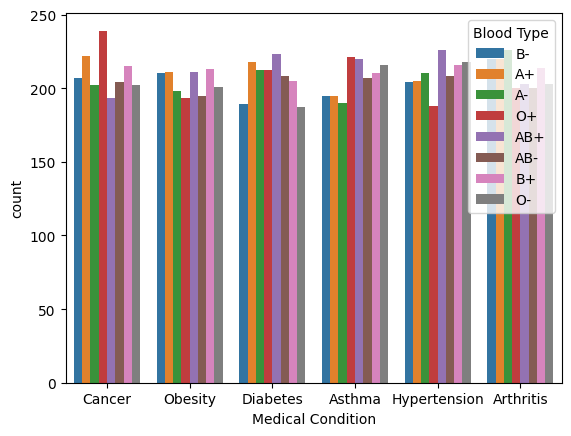

In [20]:
sns.countplot(data=df, x="Medical Condition", hue='Blood Type')
plt.show()

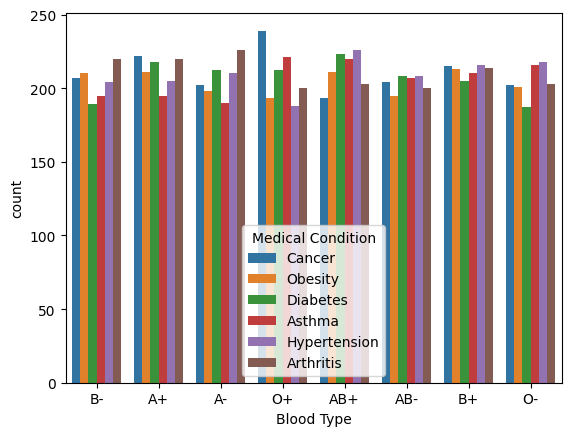

In [21]:
sns.countplot(data=df, x="Blood Type", hue='Medical Condition')
plt.show()

In [22]:
dfg = df.groupby('Medical Condition')['Blood Type'].value_counts(normalize=True)
print(dfg)

Medical Condition  Blood Type
Arthritis          A-            0.134045
                   A+            0.130486
                   B-            0.130486
                   B+            0.126928
                   AB+           0.120403
                   O-            0.120403
                   AB-           0.118624
                   O+            0.118624
Asthma             O+            0.133615
                   AB+           0.133011
                   O-            0.130593
                   B+            0.126965
                   AB-           0.125151
                   A+            0.117896
                   B-            0.117896
                   A-            0.114873
Cancer             O+            0.141924
                   A+            0.131829
                   B+            0.127672
                   B-            0.122922
                   AB-           0.121140
                   A-            0.119952
                   O-            0.119952
    

Here is a bar chart of all the medical conditions broken down by blood type, to see if there is a higher likelyhood that someone would have X medical condtion because they have Y blood type, I also wanted a visual count of these columns together, I have also fliped that bar graph around to see them grouped by blood types

In [23]:
fig = px.box(df, x ="Age Range", y ="Billing Amount")
fig.show()

Here is a set of box plots to see if the elder age ranges are being charged more then the younger age ranges

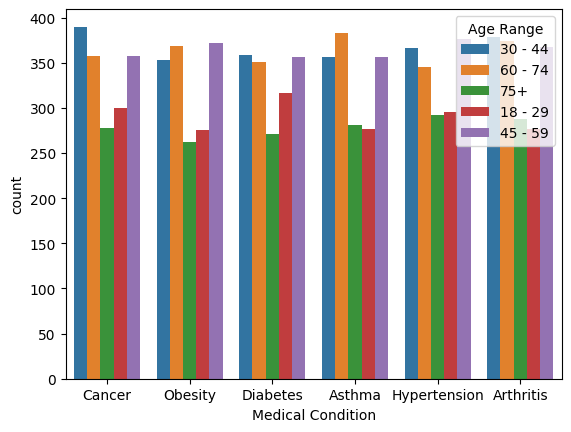

In [24]:
sns.countplot(data=df, x="Medical Condition", hue='Age Range')
plt.show()

In [25]:
fig = px.box(df, x ="Insurance Provider", y ="Billing Amount")
fig.show()

In this box plot, I wanted to check if people with different insurance providers are being billed more than others, as we can see the lowest Median is Aetna's

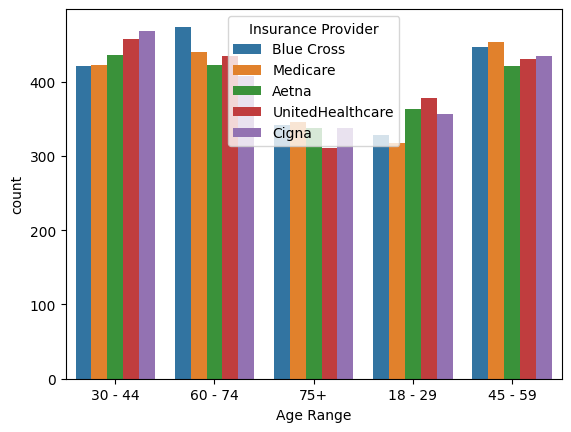

In [26]:
sns.countplot(data=df, x="Age Range", hue='Insurance Provider')
plt.show()

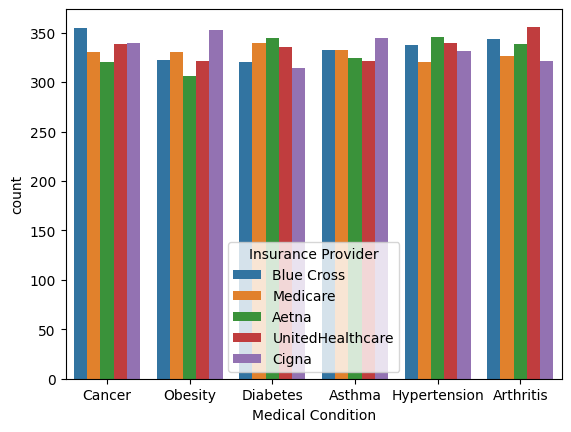

In [27]:
sns.countplot(data=df, x="Medical Condition", hue='Insurance Provider')
plt.show()

Here is a bar graph to see what insurance provider was the most common with different medical conditions, this may be because they offer better support those people

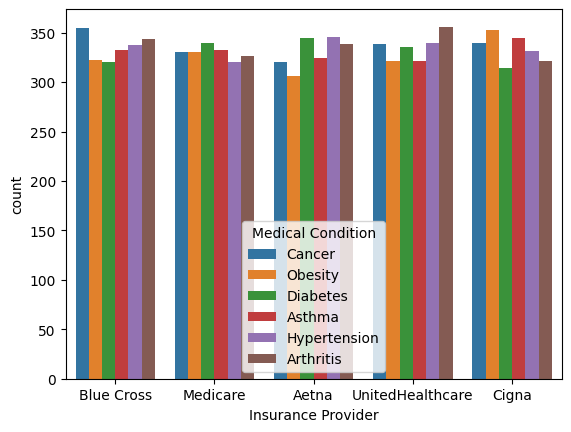

In [28]:
sns.countplot(data=df, x="Insurance Provider", hue='Medical Condition')
plt.show()

In [29]:
fig = px.box(df, x ="Medical Condition", y ="Billing Amount")
fig.show()

In [30]:
fig = px.scatter(df, x="Age", y="Billing Amount")
fig.show()

This a scatter graph for the individual ages and the billing amount

In [36]:
fig = px.scatter_3d(df, x='Date of Admission', y='Discharge Date', z='Length of Stay',
                    color='Age Range',color_continuous_scale='ice')
fig.show()

Here is a 3D scatter graph that shows the Date of Admission, Discharge Date, and Length of Stay, coloured by the Age Ranges

In [31]:
# Drop unneeded columns
X = df.drop(columns=["Patient ID", "Billing Amount", "Date of Admission", "Discharge Date", "Age Range"])
y = df["Billing Amount"]

# Identify categorical columns
categorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(exclude="object").columns

# Preprocessing + Model
preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
], remainder='passthrough')

model = Pipeline([
    ('preprocess', preprocess),
    ('regressor', LinearRegression())
])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
print("R² Score:", model.score(X_test, y_test))

R² Score: -0.00012545257289442446


In [32]:
df

,Unnamed: 0,Patient ID,Age,Age Range,Blood Type,Medical Condition,Date of Admission,Discharge Date,Length of Stay,Billing Amount,Doctor,Hospital,Insurance Provider,Medication,Test Results,Admission Type,Date_Numeric
0,0,9916905651,30,30 - 44,B-,Cancer,2024-01-31,2024-02-02,2 days,18856.28,Matthew Smith,Sons and Miller,Blue Cross,Paracetamol,Normal,Urgent,1706659200
1,1,6628734666,62,60 - 74,A+,Obesity,2019-08-20,2019-08-26,6 days,33643.33,Samantha Davies,Kim Inc,Medicare,Ibuprofen,Inconclusive,Emergency,1566259200
2,2,9816626599,76,75+,A-,Obesity,2022-09-22,2022-10-07,15 days,27955.10,Tiffany Mitchell,Cook PLC,Aetna,Aspirin,Normal,Emergency,1663804800
3,3,8154724457,28,18 - 29,O+,Diabetes,2020-11-18,2020-12-18,30 days,37909.78,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,Ibuprofen,Abnormal,Elective,1605657600
4,4,4955904392,43,30 - 44,AB+,Cancer,2022-09-19,2022-10-09,20 days,14238.32,Kathleen Hanna,White-White,Aetna,Penicillin,Abnormal,Urgent,1663545600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9980,9995,4035472565,51,45 - 59,O-,Arthritis,2019-09-25,2019-10-03,8 days,5127.44,Isaac Silva,Rice and Sons,Cigna,Ibuprofen,Normal,Urgent,1569369600
9981,9996,7649764137,61,60 - 74,B-,Diabetes,2020-06-03,2020-06-04,1 days,47855.35,Jose Cohen,"Johnson, Adkins and Ferguson",Aetna,Paracetamol,Normal,Emergency,1591142400
9982,9997,9381261822,25,18 - 29,B-,Cancer,2024-03-14,2024-03-28,14 days,40787.18,Michael Hess,Kramer-Hogan,UnitedHealthcare,Penicillin,Inconclusive,Elective,1710374400
9983,9998,3942008370,71,60 - 74,A-,Hypertension,2023-08-22,2023-09-03,12 days,25979.75,Cheryl Faulkner,"Williams Barnes and Fletcher,",Blue Cross,Lipitor,Inconclusive,Emergency,1692662400


In [33]:
y = df["Billing Amount"]
X = df.drop(columns=["Billing Amount", "Patient ID", "Date of Admission", "Discharge Date", "Age Range"])

# Identify categorical and numeric columns
categorical = X.select_dtypes(include="object").columns
numeric = X.select_dtypes(exclude="object").columns

# Preprocessing: OneHotEncode categorical features
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
], remainder="passthrough")

# Linear regression model
model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model.fit(X_train, y_train)

# Evaluate
r2 = model.score(X_test, y_test)
print(f"R² Score: {r2:.3f}")

R² Score: -0.000
